# Agente Preditivo Especialista — Heart Disease

**Disciplina:** Inteligência Artificial
**Integrantes:** Vanessa e Ana
**Dataset:** Heart Disease (Kaggle/UCI) — `heart.csv`

Este notebook cobre a **Etapa A** do projeto: pré-processamento, exploração de dados (Seaborn),
treinamento e comparação de quatro algoritmos (Regressão Logística, KNN, MLP e **Naive Bayes**),
e exportação do modelo com melhor performance para uso no backend (Etapa B).


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento dos Dados

> **Nota:** a versão original deste notebook usava `google.colab.files.upload()` para subir o
> arquivo manualmente. Como agora o projeto roda fora do Colab (localmente / no backend),
> o dataset é lido diretamente da pasta `data/heart.csv` do repositório.

In [2]:
df = pd.read_csv('../data/heart.csv')

print("Informações do dataset:")
df.info()

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [3]:
print("Estatísticas descritivas:")
df.describe().round(2)

Estatísticas descritivas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [4]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nTotal de duplicatas: {df.duplicated().sum()}")

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total de duplicatas: 1


In [5]:
# Remover duplicatas, se houver
df = df.drop_duplicates().reset_index(drop=True)

# Verificar distribuição da variável alvo
print("Distribuição da variável alvo (target):")
print(df['target'].value_counts())
print(f"\nProporção: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

Distribuição da variável alvo (target):
target
1    164
0    138
Name: count, dtype: int64

Proporção: {1: 0.543, 0: 0.457}


## 2. Exploração de Dados (Gráficos Seaborn)

Três visualizações exigidas pelo enunciado: **mapa de correlação**, **box plot** e **gráfico de frequência**.

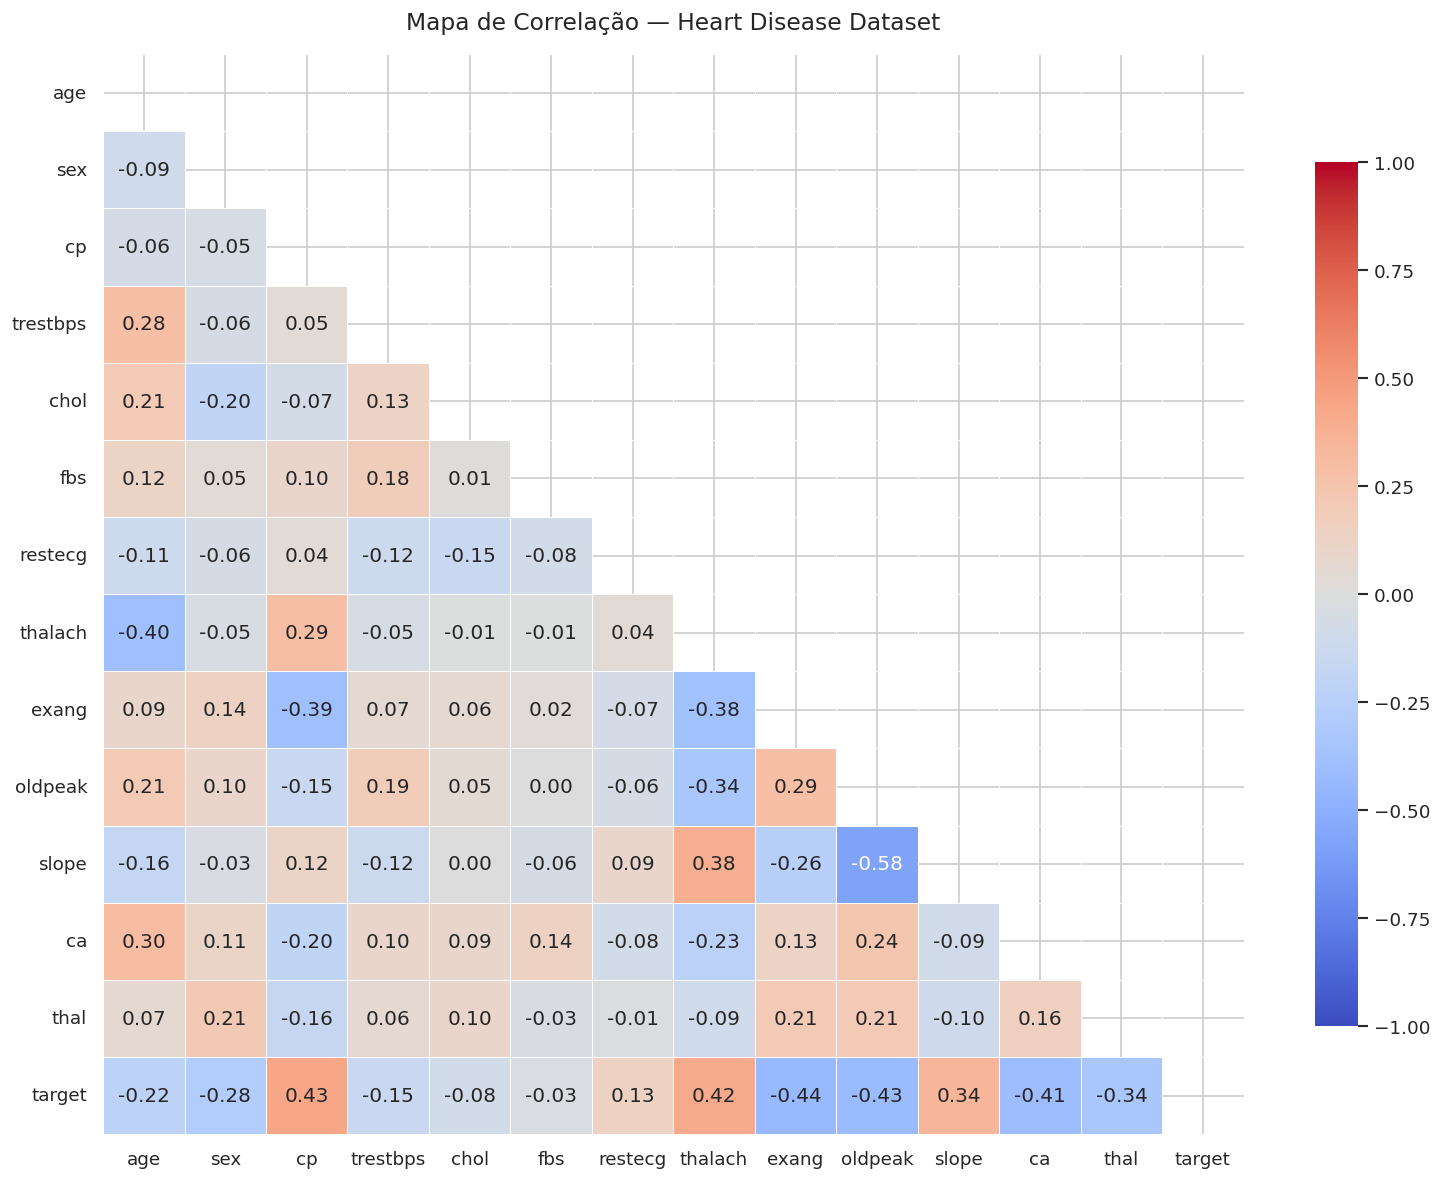

Figura salva: reports/figures/grafico_correlacao.pdf


In [6]:
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # apenas triângulo inferior
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Mapa de Correlação — Heart Disease Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/grafico_correlacao.pdf', bbox_inches='tight')
plt.show()
print("Figura salva: reports/figures/grafico_correlacao.pdf")

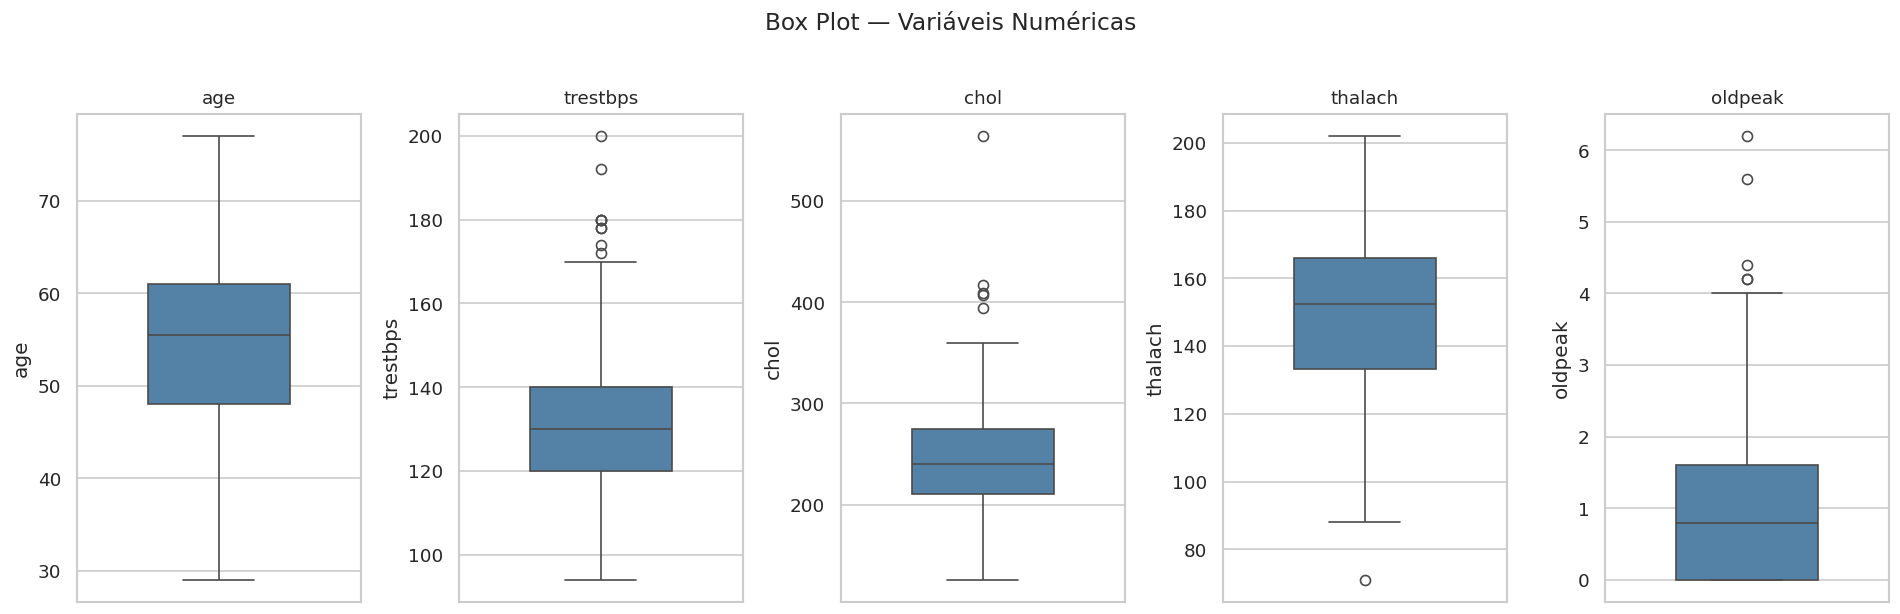

Figura salva: reports/figures/grafico_boxplot.pdf


In [7]:
features_num = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(features_num), figsize=(16, 5))
for ax, col in zip(axes, features_num):
    sns.boxplot(y=df[col], ax=ax, color='steelblue', width=0.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

fig.suptitle('Box Plot — Variáveis Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/grafico_boxplot.pdf', bbox_inches='tight')
plt.show()
print("Figura salva: reports/figures/grafico_boxplot.pdf")

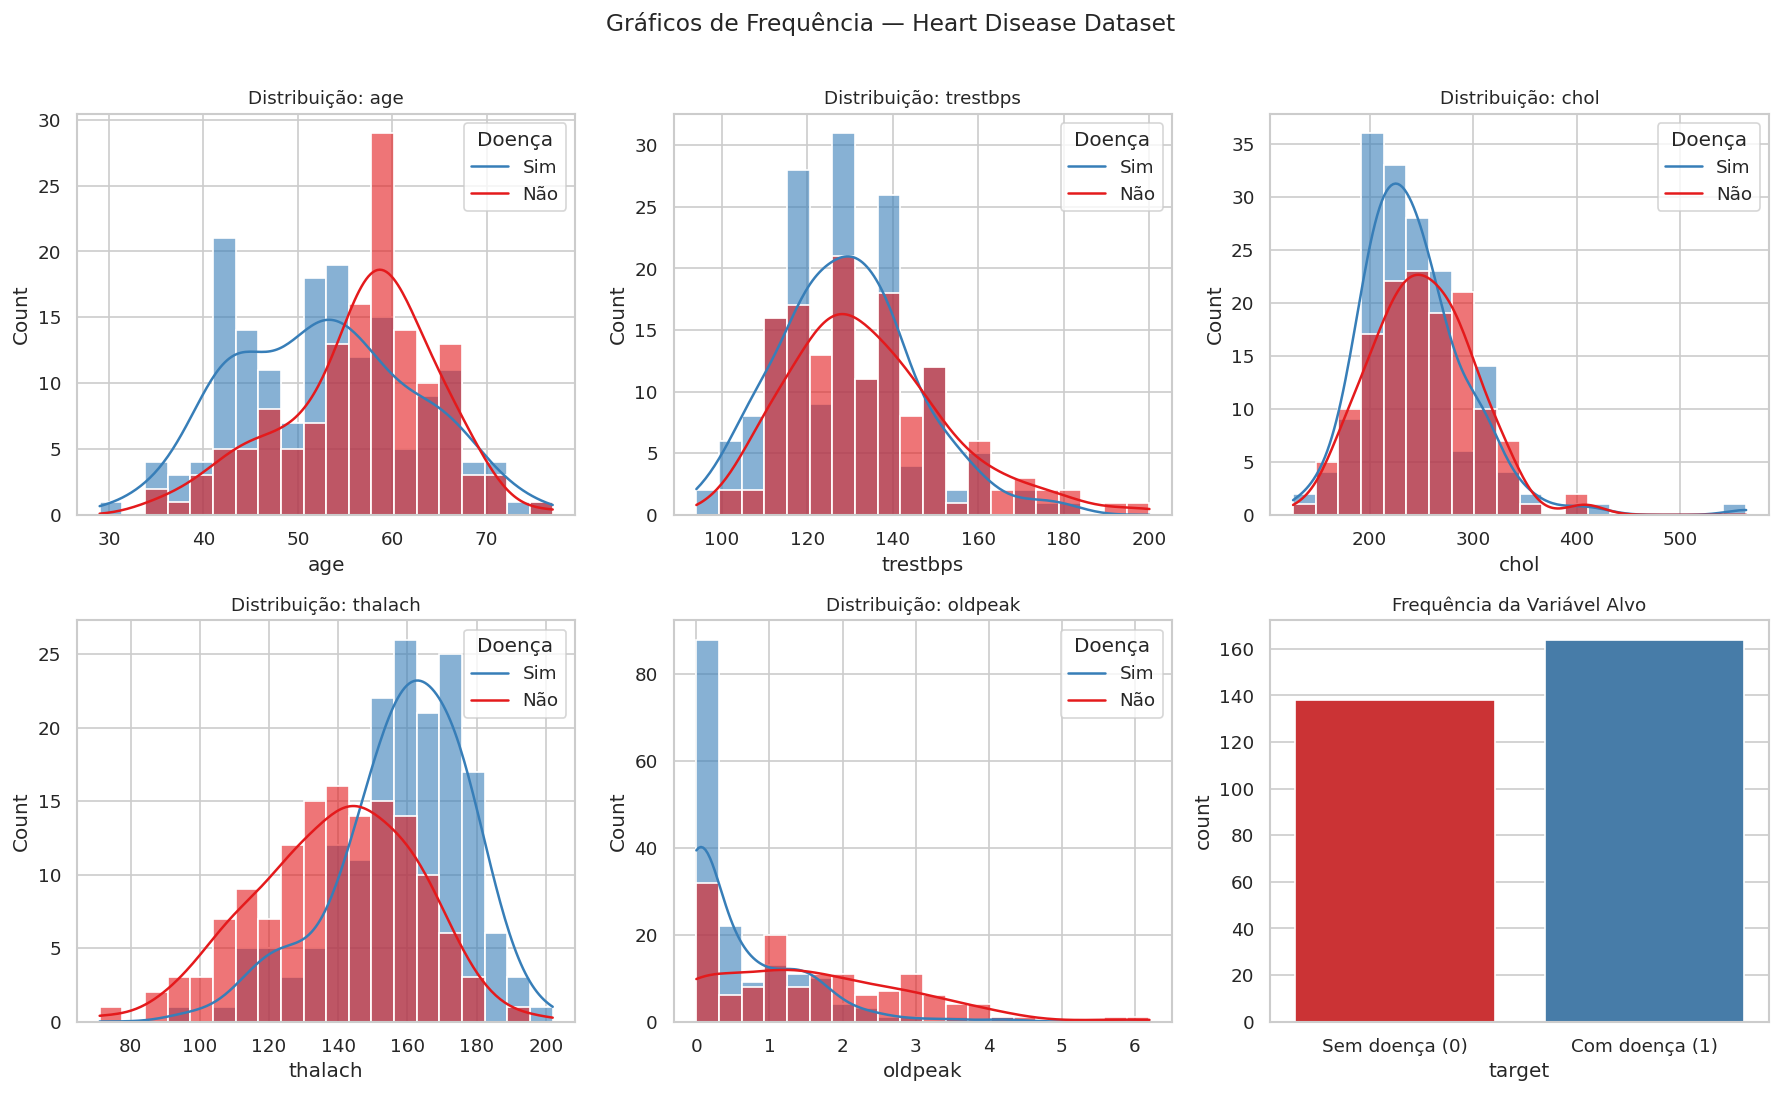

Figura salva: reports/figures/grafico_frequencia.pdf


In [8]:
features_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    sns.histplot(data=df, x=col, hue='target', bins=20,
                 kde=True, ax=axes[i], palette='Set1', alpha=0.6)
    axes[i].set_title(f'Distribuição: {col}', fontsize=11)
    axes[i].legend(title='Doença', labels=['Sim', 'Não'])

# Último subplot: contagem da variável alvo
sns.countplot(data=df, x='target', hue='target', palette='Set1', legend=False, ax=axes[5])
axes[5].set_title('Frequência da Variável Alvo', fontsize=11)
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Sem doença (0)', 'Com doença (1)'])

fig.suptitle('Gráficos de Frequência — Heart Disease Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/grafico_frequencia.pdf', bbox_inches='tight')
plt.show()
print("Figura salva: reports/figures/grafico_frequencia.pdf")

## 3. Separação Treino/Teste e Normalização

In [9]:
X = df.drop('target', axis=1)
y = df['target']

# Separação 80% treino / 20% teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Proporção treino: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Proporção teste:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Treino: 241 amostras
Teste:  61 amostras
Proporção treino: {1: 0.544, 0: 0.456}
Proporção teste:  {1: 0.541, 0: 0.459}


In [10]:
# Normalização — MinMaxScaler escala todos os valores para o intervalo [0, 1]
# Necessário pois variáveis como 'chol' (mg/dl) e 'trestbps' (mmHg) têm escalas
# muito maiores que variáveis binárias (0/1), o que distorce KNN, MLP e Naive Bayes.
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Dados normalizados com MinMaxScaler (intervalo [0, 1]).")
print("\nEstatísticas após normalização (treino):")
print(pd.DataFrame(X_train_sc, columns=X.columns).describe().round(3).loc[['min','max','mean']])

Dados normalizados com MinMaxScaler (intervalo [0, 1]).

Estatísticas após normalização (treino):
        age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
min   0.000  0.000  0.000     0.000  0.000  0.000    0.000    0.000   0.00   
max   1.000  1.000  1.000     1.000  1.000  1.000    1.000    1.000   1.00   
mean  0.528  0.685  0.313     0.353  0.418  0.141    0.276    0.544   0.34   

      oldpeak  slope     ca   thal  
min     0.000  0.000  0.000  0.000  
max     1.000  1.000  1.000  1.000  
mean    0.173  0.699  0.183  0.781  


In [11]:
def calcular_metricas(y_real, y_pred, nome_modelo=''):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    acuracia      = (tp + tn) / (tp + tn + fp + fn)
    sensibilidade = tp / (tp + fn)   # recall / TPR
    especificidade= tn / (tn + fp)   # TNR
    precisao      = tp / (tp + fp)   # precision
    f1            = 2 * (precisao * sensibilidade) / (precisao + sensibilidade)

    print(f"{'─'*45}")
    print(f"  {nome_modelo}")
    print(f"{'─'*45}")
    print(f"  Acurácia:        {acuracia:.4f} ({acuracia*100:.1f}%)")
    print(f"  Sensibilidade:   {sensibilidade:.4f}")
    print(f"  Especificidade:  {especificidade:.4f}")
    print(f"  Precisão:        {precisao:.4f}")
    print(f"  F1-Score:        {f1:.4f}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    return dict(modelo=nome_modelo, acuracia=acuracia,
                sensibilidade=sensibilidade, especificidade=especificidade,
                precisao=precisao, f1=f1)

## 4. Algoritmo 1 — Regressão Logística

> O enunciado deste trabalho menciona "Regressão Linear Múltipla", mas como o problema é de
> **classificação binária** (presença/ausência de doença cardíaca), o algoritmo correto da família
> linear é a **Regressão Logística** (já usada no trabalho anterior). A Regressão Linear pura é
> para problemas de regressão (valores contínuos), não classificação — por isso foi mantida a
> Regressão Logística aqui, evitando aplicar um algoritmo inadequado ao tipo de problema.

In [12]:
print("Testando diferentes valores de C para a Regressão Logística:\n")
for C in [0.01, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, lr.predict(X_test_sc))
    print(f"  C={C:<6} → Acurácia: {acc:.4f}")

Testando diferentes valores de C para a Regressão Logística:

  C=0.01   → Acurácia: 0.7049
  C=0.1    → Acurácia: 0.8033
  C=1      → Acurácia: 0.7869
  C=10     → Acurácia: 0.7869
  C=100    → Acurácia: 0.7869


In [13]:
# Melhor modelo — C=1 (padrão, geralmente bom)
lr_best = LogisticRegression(C=1, max_iter=1000, random_state=42)
lr_best.fit(X_train_sc, y_train)
y_pred_lr = lr_best.predict(X_test_sc)

metricas_lr = calcular_metricas(y_test, y_pred_lr, 'Regressão Logística (C=1)')

─────────────────────────────────────────────
  Regressão Logística (C=1)
─────────────────────────────────────────────
  Acurácia:        0.7869 (78.7%)
  Sensibilidade:   0.9091
  Especificidade:  0.6429
  Precisão:        0.7500
  F1-Score:        0.8219
  TP=30  FP=10  FN=3  TN=18


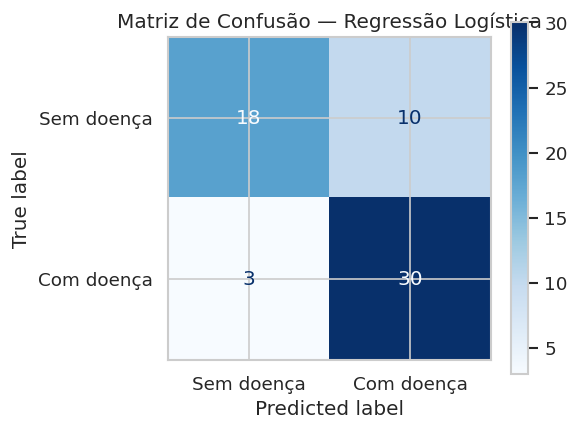

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Sem doença', 'Com doença'],
    cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão — Regressão Logística')
plt.tight_layout()
plt.savefig('../reports/figures/cm_regressao.pdf', bbox_inches='tight')
plt.show()

## 5. Algoritmo 2 — KNN (K-Nearest Neighbors)

In [15]:
# KNN com GridSearchCV — busca sistemática do melhor K
param_grid_knn = {'n_neighbors': list(range(1, 22, 2))}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_knn.fit(X_train_sc, y_train)

melhor_k   = grid_knn.best_params_['n_neighbors']
melhor_acc = grid_knn.best_score_

print(f"Resultados do GridSearchCV para KNN (CV=5):\n")
resultados_knn = []
for params, mean_score in zip(
        grid_knn.cv_results_['params'],
        grid_knn.cv_results_['mean_test_score']):
    k = params['n_neighbors']
    resultados_knn.append((k, mean_score))
    print(f"  K={k:<3} → Acurácia média (CV): {mean_score:.4f}")

print(f"\n→ Melhor K: {melhor_k} com acurácia média (CV) de {melhor_acc:.4f}")

Resultados do GridSearchCV para KNN (CV=5):

  K=1   → Acurácia média (CV): 0.7599
  K=3   → Acurácia média (CV): 0.7929
  K=5   → Acurácia média (CV): 0.7886
  K=7   → Acurácia média (CV): 0.7971
  K=9   → Acurácia média (CV): 0.8054
  K=11  → Acurácia média (CV): 0.7971
  K=13  → Acurácia média (CV): 0.7971
  K=15  → Acurácia média (CV): 0.7970
  K=17  → Acurácia média (CV): 0.7805
  K=19  → Acurácia média (CV): 0.7970
  K=21  → Acurácia média (CV): 0.7847

→ Melhor K: 9 com acurácia média (CV) de 0.8054


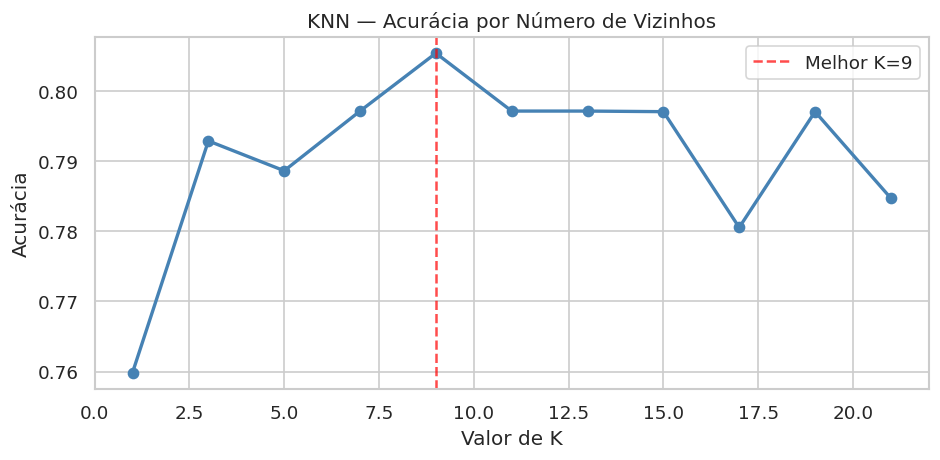

In [16]:
# Gráfico da acurácia por K
ks, accs = zip(*resultados_knn)
plt.figure(figsize=(8, 4))
plt.plot(ks, accs, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.axvline(melhor_k, color='red', linestyle='--', alpha=0.7, label=f'Melhor K={melhor_k}')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.title('KNN — Acurácia por Número de Vizinhos')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/knn_parametros.pdf', bbox_inches='tight')
plt.show()

In [17]:
knn_best = KNeighborsClassifier(n_neighbors=melhor_k)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)

metricas_knn = calcular_metricas(y_test, y_pred_knn, f'KNN (K={melhor_k})')

─────────────────────────────────────────────
  KNN (K=9)
─────────────────────────────────────────────
  Acurácia:        0.7705 (77.0%)
  Sensibilidade:   0.8485
  Especificidade:  0.6786
  Precisão:        0.7568
  F1-Score:        0.8000
  TP=28  FP=9  FN=5  TN=19


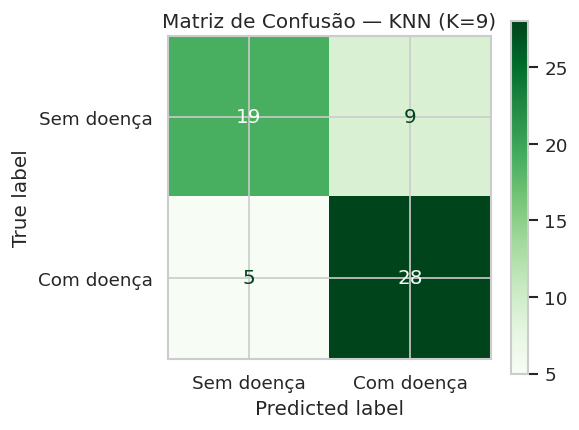

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn,
    display_labels=['Sem doença', 'Com doença'],
    cmap='Greens', ax=ax)
ax.set_title(f'Matriz de Confusão — KNN (K={melhor_k})')
plt.tight_layout()
plt.savefig('../reports/figures/cm_knn.pdf', bbox_inches='tight')
plt.show()

## 6. Algoritmo 3 — MLP (Multi-Layer Perceptron)

In [19]:
# MLP com GridSearchCV — busca sistemática da melhor arquitetura e ativação
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (50, 30, 10)],
    'activation'        : ['relu', 'tanh'],
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=42),
    param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_mlp.fit(X_train_sc, y_train)

melhor_cfg = grid_mlp.best_params_
melhor_acc_mlp = grid_mlp.best_score_

print("Resultados do GridSearchCV para MLP (CV=5):\n")
for params, mean_score in sorted(
        zip(grid_mlp.cv_results_['params'],
            grid_mlp.cv_results_['mean_test_score']),
        key=lambda x: -x[1]):
    print(f"  camadas={str(params['hidden_layer_sizes']):<16} "
          f"activation={params['activation']:<5} → Acurácia média (CV): {mean_score:.4f}")

print(f"\n→ Melhor configuração: camadas={melhor_cfg['hidden_layer_sizes']}, "
      f"activation={melhor_cfg['activation']}")
print(f"→ Acurácia média (CV): {melhor_acc_mlp:.4f}")

Resultados do GridSearchCV para MLP (CV=5):

  camadas=(50,)            activation=relu  → Acurácia média (CV): 0.8264
  camadas=(100,)           activation=tanh  → Acurácia média (CV): 0.8260
  camadas=(100, 100)       activation=tanh  → Acurácia média (CV): 0.8177
  camadas=(50,)            activation=tanh  → Acurácia média (CV): 0.8138
  camadas=(50, 30, 10)     activation=tanh  → Acurácia média (CV): 0.8096
  camadas=(100, 50)        activation=relu  → Acurácia média (CV): 0.8095
  camadas=(100, 100)       activation=relu  → Acurácia média (CV): 0.8054
  camadas=(100,)           activation=relu  → Acurácia média (CV): 0.8013
  camadas=(50, 30, 10)     activation=relu  → Acurácia média (CV): 0.7973
  camadas=(100, 50)        activation=tanh  → Acurácia média (CV): 0.7848

→ Melhor configuração: camadas=(50,), activation=relu
→ Acurácia média (CV): 0.8264


In [20]:
mlp_best = MLPClassifier(
    hidden_layer_sizes=melhor_cfg['hidden_layer_sizes'],
    activation=melhor_cfg['activation'],
    max_iter=2000,
    random_state=42
)
mlp_best.fit(X_train_sc, y_train)
y_pred_mlp = mlp_best.predict(X_test_sc)

metricas_mlp = calcular_metricas(
    y_test, y_pred_mlp,
    f"MLP {melhor_cfg['hidden_layer_sizes']} {melhor_cfg['activation']}"
)

─────────────────────────────────────────────
  MLP (50,) relu
─────────────────────────────────────────────
  Acurácia:        0.8033 (80.3%)
  Sensibilidade:   0.8788
  Especificidade:  0.7143
  Precisão:        0.7838
  F1-Score:        0.8286
  TP=29  FP=8  FN=4  TN=20


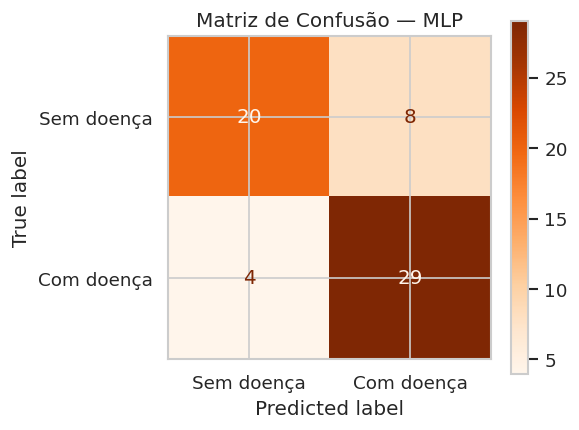

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp,
    display_labels=['Sem doença', 'Com doença'],
    cmap='Oranges', ax=ax)
ax.set_title('Matriz de Confusão — MLP')
plt.tight_layout()
plt.savefig('../reports/figures/cm_mlp.pdf', bbox_inches='tight')
plt.show()

## 7. Algoritmo 4 — Naive Bayes *(novo neste trabalho)*

O Naive Bayes é um classificador probabilístico baseado no **Teorema de Bayes**, que assume
(de forma "ingênua") **independência condicional entre as variáveis** dado o valor da classe.
Como o dataset possui variáveis numéricas contínuas (idade, colesterol, frequência cardíaca, etc.),
usamos a variante **Gaussiana (`GaussianNB`)**, que modela cada atributo como tendo distribuição
normal dentro de cada classe.

**Por que testar Naive Bayes aqui?**
- É extremamente rápido para treinar e prever (sem necessidade de GridSearch pesado).
- Funciona bem mesmo com poucos dados — relevante pois o dataset tem apenas ~300 registros.
- Serve de **baseline probabilístico** para comparar com os modelos mais complexos (MLP) e
  baseados em distância (KNN).

In [22]:
nb_best = GaussianNB()
nb_best.fit(X_train_sc, y_train)
y_pred_nb = nb_best.predict(X_test_sc)

metricas_nb = calcular_metricas(y_test, y_pred_nb, 'Naive Bayes (Gaussian)')

─────────────────────────────────────────────
  Naive Bayes (Gaussian)
─────────────────────────────────────────────
  Acurácia:        0.8197 (82.0%)
  Sensibilidade:   0.9091
  Especificidade:  0.7143
  Precisão:        0.7895
  F1-Score:        0.8451
  TP=30  FP=8  FN=3  TN=20


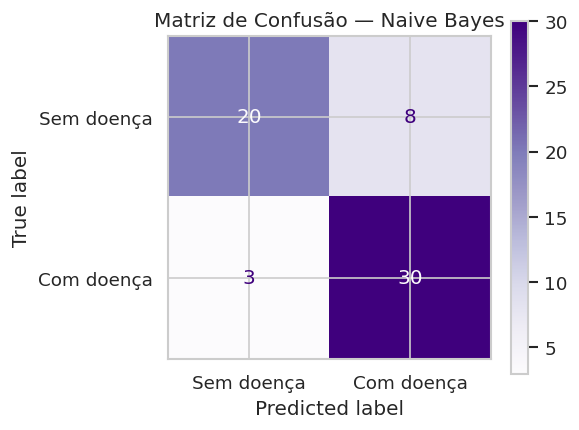

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb,
    display_labels=['Sem doença', 'Com doença'],
    cmap='Purples', ax=ax)
ax.set_title('Matriz de Confusão — Naive Bayes')
plt.tight_layout()
plt.savefig('../reports/figures/cm_naive_bayes.pdf', bbox_inches='tight')
plt.show()

## 8. Comparação Final dos 4 Algoritmos

In [24]:
tabela = pd.DataFrame([metricas_lr, metricas_knn, metricas_mlp, metricas_nb])
tabela = tabela.set_index('modelo').round(4)

print("\n" + "="*65)
print("COMPARAÇÃO DAS MÉTRICAS DOS MODELOS")
print("="*65)
print(tabela.to_string())
print("="*65)
tabela


COMPARAÇÃO DAS MÉTRICAS DOS MODELOS
                           acuracia  sensibilidade  especificidade  precisao      f1
modelo                                                                              
Regressão Logística (C=1)    0.7869         0.9091          0.6429    0.7500  0.8219
KNN (K=9)                    0.7705         0.8485          0.6786    0.7568  0.8000
MLP (50,) relu               0.8033         0.8788          0.7143    0.7838  0.8286
Naive Bayes (Gaussian)       0.8197         0.9091          0.7143    0.7895  0.8451


,acuracia,sensibilidade,especificidade,precisao,f1
modelo,,,,,
Regressão Logística (C=1),0.7869,0.9091,0.6429,0.7500,0.8219
KNN (K=9),0.7705,0.8485,0.6786,0.7568,0.8000
"MLP (50,) relu",0.8033,0.8788,0.7143,0.7838,0.8286
Naive Bayes (Gaussian),0.8197,0.9091,0.7143,0.7895,0.8451


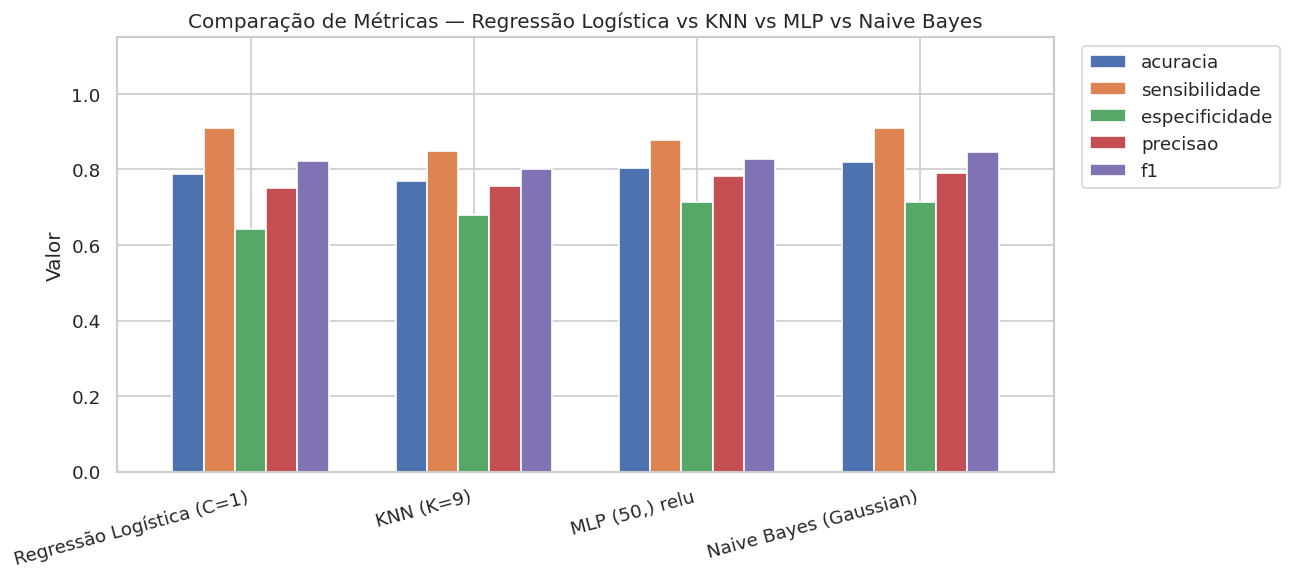

In [25]:
# Gráfico comparativo em barras
fig, ax = plt.subplots(figsize=(11, 5))
tabela[['acuracia', 'sensibilidade', 'especificidade', 'precisao', 'f1']].plot(
    kind='bar', ax=ax, edgecolor='white', width=0.7,
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
)
ax.set_ylim(0, 1.15)
ax.set_xlabel('')
ax.set_xticklabels(tabela.index, rotation=15, ha='right')
ax.set_ylabel('Valor')
ax.set_title('Comparação de Métricas — Regressão Logística vs KNN vs MLP vs Naive Bayes')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.savefig('../reports/figures/comparacao_modelos.pdf', bbox_inches='tight')
plt.show()

### Análise crítica rápida

| Modelo | Vantagens | Limitações |
|---|---|---|
| **Regressão Logística** | Simples, interpretável (coeficientes), rápida | Assume relação linear entre variáveis e log-odds da classe |
| **KNN** | Não-paramétrico, captura padrões não-lineares | Sensível à escala e a outliers; lento em bases grandes; exige escolher K |
| **MLP** | Captura relações não-lineares complexas | "Caixa-preta", precisa de mais dados/tuning, risco de overfitting em base pequena |
| **Naive Bayes** | Rápido, funciona bem com poucos dados, probabilístico | Assume independência entre variáveis (raramente verdadeira na prática) |

*(Preencher com os números reais obtidos na tabela acima ao escrever o relatório técnico.)*

## 9. Seleção e Exportação do Melhor Modelo

Selecionamos automaticamente o modelo com **maior acurácia** no conjunto de teste, e exportamos:
- o modelo treinado (`.pkl`)
- o `scaler` usado no pré-processamento (necessário para transformar novos dados de entrada)
- metadados (nome do modelo, métricas, ordem das colunas) em `.json`

Esses arquivos serão consumidos diretamente pelo **backend FastAPI** (Etapa B).

In [26]:
import os
os.makedirs('../backend/artifacts', exist_ok=True)

modelos_treinados = {
    'Regressão Logística (C=1)': lr_best,
    f'KNN (K={melhor_k})': knn_best,
    f"MLP {melhor_cfg['hidden_layer_sizes']} {melhor_cfg['activation']}": mlp_best,
    'Naive Bayes (Gaussian)': nb_best,
}

melhor_nome = tabela['acuracia'].idxmax()
melhor_modelo = modelos_treinados[melhor_nome]
melhor_acc_final = tabela.loc[melhor_nome, 'acuracia']

print(f"🏆 Melhor modelo: {melhor_nome}")
print(f"   Acurácia no teste: {melhor_acc_final:.4f}")

# Exporta modelo + scaler
joblib.dump(melhor_modelo, '../backend/artifacts/modelo_final.pkl')
joblib.dump(scaler, '../backend/artifacts/scaler.pkl')

# Exporta metadados
metadados = {
    'modelo_escolhido': melhor_nome,
    'colunas_entrada': list(X.columns),
    'metricas_teste': tabela.loc[melhor_nome].to_dict(),
    'todas_as_metricas': tabela.reset_index().to_dict(orient='records'),
}
with open('../backend/artifacts/metadados.json', 'w', encoding='utf-8') as f:
    json.dump(metadados, f, indent=2, ensure_ascii=False)

print("\nArquivos exportados em backend/artifacts/:")
print("  - modelo_final.pkl")
print("  - scaler.pkl")
print("  - metadados.json")

🏆 Melhor modelo: Naive Bayes (Gaussian)
   Acurácia no teste: 0.8197

Arquivos exportados em backend/artifacts/:
  - modelo_final.pkl
  - scaler.pkl
  - metadados.json


## 10. Dicionário de Variáveis (para referência no frontend/backend)

| Coluna | Descrição | Valores |
|---|---|---|
| `age` | Idade do paciente | anos |
| `sex` | Sexo | 1 = masculino, 0 = feminino |
| `cp` | Tipo de dor no peito | 0–3 (0=típica, 1=atípica, 2=não-anginosa, 3=assintomática) |
| `trestbps` | Pressão arterial em repouso | mmHg |
| `chol` | Colesterol sérico | mg/dl |
| `fbs` | Glicemia de jejum > 120 mg/dl | 1 = sim, 0 = não |
| `restecg` | Resultado do eletrocardiograma em repouso | 0–2 |
| `thalach` | Frequência cardíaca máxima atingida | bpm |
| `exang` | Angina induzida por exercício | 1 = sim, 0 = não |
| `oldpeak` | Depressão do segmento ST induzida por exercício | valor numérico |
| `slope` | Inclinação do segmento ST no pico do exercício | 0–2 |
| `ca` | Número de vasos principais coloridos por fluoroscopia | 0–4 |
| `thal` | Talassemia | 0=normal, 1=defeito fixo, 2=defeito reversível |
| `target` | Diagnóstico (variável alvo) | 1 = presença de doença, 0 = ausência |
